In [4]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

local_address = "nova-14.lyon.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

In [5]:
exp_q1 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 30, 10, 19, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 10, 24, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 30, 10, 27, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 10, 32, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 30, 10, 35, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 10, 40, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 30, 10, 42, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 10, 47, 0, tzinfo=local_tz)
    }
}

exp_q2 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 29, 15, 0, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 15, 5, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 29, 15, 10, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 15, 15, 30, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 29, 15, 22, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 15, 27, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 29, 15, 34, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 15, 39, 0, tzinfo=local_tz)
    }
}
exp_q3 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 29, 14, 49, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 14, 52, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 29, 14, 26, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 14, 31, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 29, 14, 34, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 14, 39, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 29, 14, 41, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 14, 46, 30, tzinfo=local_tz)
    }
}
exp_q5 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 28, 14, 49, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 14, 54, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 28, 14, 57, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 15, 2, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 28, 15, 5, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 15, 10, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 28, 15, 12, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 15, 17, 0, tzinfo=local_tz)
    }
}

exp_q8 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 29, 10, 35, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 10, 40, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 29, 10, 56, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 1, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 29, 11, 13, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 18, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 29, 11, 33, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 38, 0, tzinfo=local_tz)
    }
}

exp_q11 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 29, 11, 48, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 53, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 29, 11, 57, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 12, 2, 30, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 29, 12, 4, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 12, 9, 30, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 29, 12, 13, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 12, 18, 0, tzinfo=local_tz)
    }
}


In [6]:
metric_query = 'sum(rate(flink_taskmanager_job_task_operator_numRecordsOut{operator_name=~"Source:.*"}[1m]))'
step = "5s"
output_filename = 'exp2a_q1_tput.csv'

execute_query_range(exp_q1, metric_query, step, output_filename)


Beginning request execution

File saved : 'exp2a_q1_tput.csv'


### BoxPlot

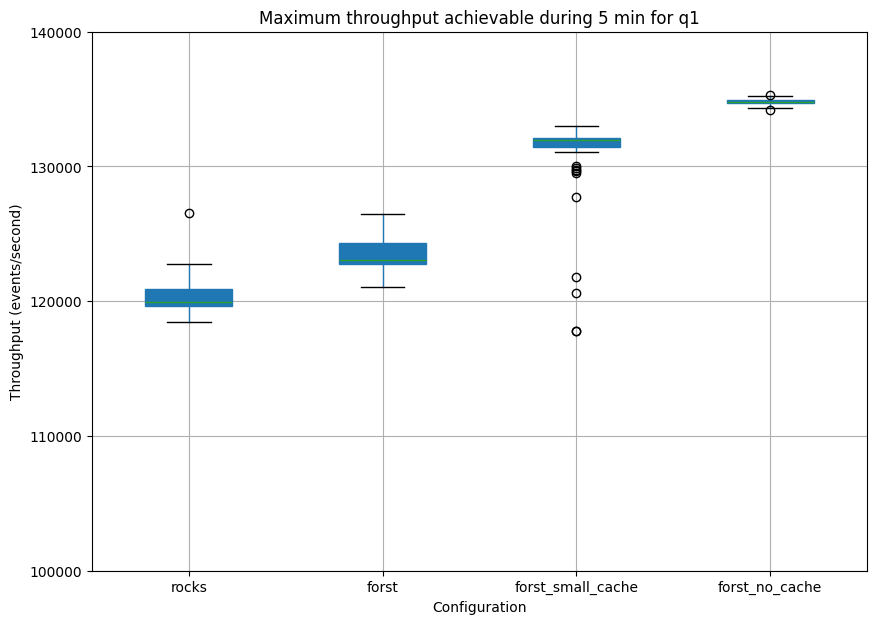

In [7]:
file_path = 'exp2a_q1_tput.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    
    df.columns = ['rocks', 'forst', 'forst_small_cache', 'forst_no_cache']
    
    plt.figure(figsize=(10, 7))
    df.boxplot(grid=True, patch_artist=True)
    
    plt.title('Maximum throughput achievable during 5 min for q1')
    plt.ylabel('Throughput (events/second)')
    plt.xlabel('Configuration')
    plt.yticks(np.arange(100000, 150000, 10000))
    plt.savefig('boxplot_q1.png')
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")